In [28]:
import os
import sys
import math
import datetime
import collections
import requests
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

from Modules.order import (
    Order, 
    BuyMarketOrderAsPossible,
    BuyMarketOrderMoreThan,
    SellMarketOrder
)
from Modules.portfolio import Portfolio
from Modules.utility import Utility

In [29]:
# APIの接続先（notebookコンテナでは通常 http://api:8000 が設定される）
API_BASE_URL = os.getenv("API_BASE_URL", "http://localhost:8000")
# データを取得する関数
sys.path.append("/workspace/notebook")

In [30]:
stocks_df = pd.DataFrame()
get_url = f"{API_BASE_URL}/api/v1/stocks/"
get_params = {}
get_response = requests.get(get_url, params=get_params, timeout=60)

if get_response.status_code == 200:
    get_json = get_response.json()
    results = get_json.get("results", [])
    stocks_df = pd.DataFrame(results)
else:
    print("GET response:", get_response.json())
stocks_df.head()

,id,code,market,currency_id,name,sector,memo,created_at,updated_at,currency
0,1,ENEL.MI,BIT,16,None,None,None,2026-04-22T10:41:11.170277Z,2026-04-22T10:41:11.170277Z,EUR
1,2,LDO.MI,BIT,16,None,None,None,2026-04-22T10:41:15.240746Z,2026-04-22T10:41:15.240746Z,EUR
2,3,ORSTED.CO,CPH,17,None,None,None,2026-04-22T10:41:17.629111Z,2026-04-22T10:41:17.629111Z,DKK
3,4,VWS.CO,CPH,17,None,None,None,2026-04-22T10:41:19.783396Z,2026-04-22T10:41:19.783396Z,DKK
4,5,DSY.PA,EPA,18,None,None,None,2026-04-22T10:41:25.639888Z,2026-04-22T10:41:25.639888Z,EUR


In [31]:
def simulate(stat_date, end_date, deposit, trade_func, get_open_price_func, get_close_price_func):
    """
    [start_date, end_date]の範囲内の売買シミュレーションを行う
    deposit: 最初の所持金
    trade_func: シミュレーションする取引関数
    get_open_price_func: 指定銘柄コードの始値を取得する関数
    get_close_price_func: 指定銘柄コードの終値を取得する関数
    """
    portfolio = Portfolio(deposit)
    utility = Utility()

    total_price_list = []
    profit_or_loss_list = []
    
    def record(d):
        # 本日(d)の損益などを記録
        current_total_price = portfolio.calc_current_total_price(
            lambda code: get_close_price_func(d, code))
        total_price_list.append(current_total_price)
        profit_or_loss_list.append(current_total_price
                                   - portfolio.amount_of_investment)

    def execute_order(d, orders):
        # 本日(d)において注文(orders)をすべて執行する
        for order in orders:
            order.execute(d, portfolio,
                          lambda code: get_open_price_func(d, code))
    
    order_list = []
    date_range = [pdate.to_pydatetime().date() for pdate in utility.tse_date_range(stat_date, end_date)]
    for date in date_range[:-1]:
        execute_order(date, order_list)
        order_list = trade_func(date, portfolio)
        record(date)

    # 最終日に保有株は全て売却する
    last_date = date_range[-1]
    execute_order(last_date, 
                  [SellMarketOrder(code=code, count=stock.current_count) for code, stock in portfolio.stocks.items()])
    record(last_date)

    return portfolio, \
        pd.DataFrame(data={'price': total_price_list, 
                           'profit': profit_or_loss_list}, 
                    index=date_range)

In [32]:
def create_stock_data(
    code_list: list,
    stocks_df: pd.DataFrame,
    start_date: str,
    end_date: str
) -> dict:
    """
    指定した銘柄(code_list)それぞれの単元株数と日足(始値・終値）を含む辞書を作成
    sqlite3版と同じく、pricesはDataFrame（index=date, columns=['open', 'close']）で返す
    """
    utility = Utility()
    stocks = {}
    # TSE営業日インデックスを作成（API版はutility.tse_date_rangeを想定）
    tse_index = utility.tse_date_range(start_date, end_date)
    for code in code_list:
        unit = 1
        stock = stocks_df[(stocks_df['code'] == code['code']) & (stocks_df['market'] == code['market'])]
        time_series_data = utility.get_stock_time_series_data(
            code=code['code'],
            market=code['market'],
            start=start_date,
            end=end_date
        )
        if not stock.empty and not time_series_data.empty:
            if stock['market'].iloc[0] == 'TSE':
                unit = 100
            # 必要なカラムのみ抽出（sqlite3版はopen/closeのみ）
            price_cols = [col for col in ['open', 'close'] if col in time_series_data.columns]
            prices_df = time_series_data[['date'] + price_cols].copy()
            prices_df['date'] = pd.to_datetime(prices_df['date'])
            prices_df.set_index('date', inplace=True)
            prices_df.index = pd.to_datetime(prices_df.index)
            # open/close列をfloat型に統一
            for col in price_cols:
                prices_df[col] = prices_df[col].astype(float)
            # indexをTSE営業日に揃え、ffill
            prices_df = prices_df.reindex(pd.to_datetime(tse_index), method='ffill')
            stocks[code['code']] = {'unit': unit, 'prices': prices_df}
    return stocks

In [33]:
def generate_cross_date_list(prices):
    """指定した日足データよりゴールデンクロス・デッドクロスが生じた日のリストを生成
    """
    # 移動平均を求める
    sma_5 = prices.rolling(window=5).mean()
    sma_25 = prices.rolling(window=25).mean()

    # ゴールデンクロス・デッドクロスが発生した場所を得る
    sma_5_over_25 = sma_5 > sma_25
    cross = sma_5_over_25 != sma_5_over_25.shift(1)
    golden_cross = cross & (sma_5_over_25 == True)
    dead_cross = cross & (sma_5_over_25 == False)
    golden_cross.drop(golden_cross.head(25).index, inplace=True)
    dead_cross.drop(dead_cross.head(25).index, inplace=True)

    # 日付のリストに変換
    golden_list = [x.date()
                   for x
                   in golden_cross[golden_cross].index.to_pydatetime()] 
    dead_list = [x.date()
                 for x
                 in dead_cross[dead_cross].index.to_pydatetime()]
    return golden_list, dead_list

def simulate_golden_dead_cross(
        stocks_df: pd.DataFrame,
        start_date: datetime.date, 
        end_date: datetime.date,
        code_list: list,
        deposit: int,
        order_under_limit: int
    ):
    """
    deposit: 初期の所持金
    order_order_under_limit: ゴールデンクロス時の最小購入金額 
    """
    
    stocks = create_stock_data(
        code_list=code_list, 
        stocks_df=stocks_df, 
        start_date=start_date, 
        end_date=end_date
    )
    # {ゴールデンクロス・デッドクロスが発生した日 : 発生した銘柄のリスト}
    # の辞書を作成
    golden_dict = defaultdict(list)
    dead_dict = defaultdict(list)
    for code in code_list:
        prices = stocks[code['code']]['prices']['close']
        golden, dead = generate_cross_date_list(prices)
        for l, d in zip((golden, dead), (golden_dict, dead_dict)):
            for date in l:
                d[date].append(code['code'])

    def get_open_price_func(date, code):
        return stocks[code]['prices']['open'][pd.Timestamp(date)]
    
    def get_close_price_func(date, code):
        return stocks[code]['prices']['close'][pd.Timestamp(date)]

    def trade_func(date, portfolio):
        order_list = []
        # Dead crossが発生していて持っている株があれば売る
        if date in dead_dict:
            for code in dead_dict[date]:
                if code in portfolio.stocks:
                    order_list.append(
                        SellMarketOrder(code,
                                            portfolio.stocks[code].current_count))
        # 保有していない株でgolden crossが発生していたら買う
        if date in golden_dict:
            for code in golden_dict[date]:
                if code not in portfolio.stocks:
                    order_list.append(
                        BuyMarketOrderMoreThan(code,
                                                   stocks[code]['unit'],
                                                   order_under_limit))
        return order_list

    return simulate(start_date, end_date,
                        deposit,
                        trade_func,
                        get_open_price_func, get_close_price_func)

In [34]:
code_list = [
    {'code': '7701', 'market': 'TSE'},
    {'code': '7735', 'market': 'TSE'},
]

In [35]:
deposit = 1000000

In [36]:
order_under_limit = 100000

In [37]:
portfolio, result = simulate_golden_dead_cross(
    stocks_df=stocks_df,
    start_date=datetime.date(2025, 1, 1),
    end_date=datetime.date(2026, 4, 17),
    code_list=code_list,
    deposit=deposit,
    order_under_limit=order_under_limit
)

取得件数: 515
取得件数: 515
2025-02-21 BUY code:7735 count:100 price:5665.86865234375 deposit:1000000 -> 432889
2025-03-13 SELL code:7735 count:100 price:5258.06103515625 deposit:432889 -> 958170
2025-03-18 BUY code:7735 count:100 price:5344.931640625 deposit:958170 -> 423152
2025-03-19 BUY code:7701 count:100 price:3854.01513671875 deposit:423152 -> 37481
2025-03-26 SELL code:7701 count:100 price:3802.472900390625 deposit:37481 -> 417458
2025-03-26 SELL code:7735 count:100 price:5142.234375 deposit:417458 -> 931156
2025-04-30 BUY code:7701 count:100 price:3603.685791015625 deposit:931156 -> 570518
2025-04-30 BUY code:7735 count:100 price:4650.35107421875 deposit:570518 -> 105213
2025-05-16 SELL code:7701 count:100 price:3383.61328125 deposit:105213 -> 443304
2025-06-06 SELL code:7735 count:100 price:5316.65234375 deposit:443304 -> 974444
2025-06-11 BUY code:7735 count:100 price:5380.53125 deposit:974444 -> 435866
2025-06-13 BUY code:7701 count:100 price:3514.28125 deposit:435866 -> 84168
2025

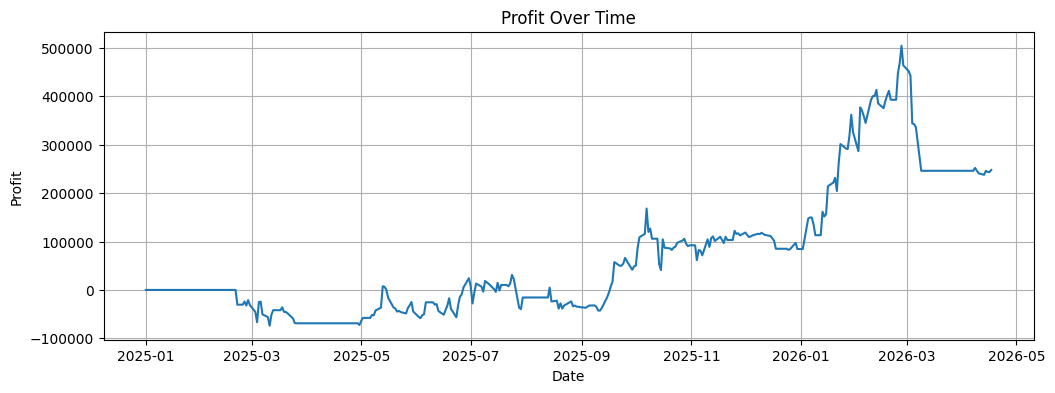

In [38]:
result['profit'].plot(figsize=(12, 4))
plt.title("Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.grid(True)
plt.show()
